In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import pickle
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-03-03 21:31:02.234063


#### Functions

In [3]:
def age_tag(flt_age):
    if flt_age >= 60:
        return 1
    else:
        return 0

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

int_n_iterations = 100
int_n_early_stopping = 5

Project: 20241112-simple-model-test
Task: 09_60_in_720


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import model

In [6]:
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
list_cols_model = [col.split('_binned')[0] for col in list_cols_model]
print(f'There are {len(list_cols_model)} features in the model')

There are 45 features in the model


#### Import data

In [7]:
# get cols to import
list_cols_id = [
    'accountid',
    'request_datetime',
    'bitdebtor',
    'subjectage__ln',
]
list_cols_import = list_cols_id + list_cols_model
# import
str_filename_tmp = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename_tmp}'
df = pd.read_parquet(
    str_uri,
    columns=list_cols_import,
)
# clean up subject age
df['subjectage__ln'] = df['subjectage__ln'].mask(df['subjectage__ln'] < 0, np.nan)
flt_mdn = df['subjectage__ln'].median()
print(f'Missing age imputed with {flt_mdn:0.2f}')
df['subjectage__ln'] = df['subjectage__ln'].fillna(flt_mdn)
# create tag
df['tag_age'] = df['subjectage__ln'].apply(age_tag)
# show
df

Missing age imputed with 42.00


,accountid,request_datetime,bitdebtor,subjectage__ln,fltgrossmonthly__income_sum,au20s__tu,miles_odometer__app,rtl_trd__tu,ENG-loan_to_value,g002s__tu,...,fi36s__tu,linkf098__tu,linka006__tu,inquiryshortterm12month__ln,addrinputsubjectcount__ln,g251c__tu,g095s__tu,s209a__tu,inquirynonshortterm12month__ln,tag_age
37865,5514485,2022-10-15 02:35:52.2455863,1,48.0,3976.280029,4.0,44878.0,0.0,1.299997,0.0,...,999.0,NaN,2.0,0.0,0.0,0.0,NaN,NaN,1.0,0
37866,5514970,2022-10-15 02:36:32.6396499,1,32.0,5720.000000,52.0,26828.0,0.0,1.295059,0.0,...,18.0,0.0,2.0,0.0,3.0,6.0,NaN,5.0,1.0,0
37869,5515245,2022-10-15 02:36:53.5525392,1,34.0,4822.600098,101.0,1456.0,0.0,1.156227,0.0,...,1.0,0.0,12.0,0.0,NaN,1.0,NaN,13.0,1.0,0
37870,5515340,2022-10-15 02:37:13.5377961,1,46.0,4160.000000,NaN,83463.0,0.0,1.599743,NaN,...,13.0,0.0,3.0,0.0,NaN,1.0,NaN,NaN,0.0,0
37871,5515580,2022-10-15 02:37:34.1144830,0,32.0,2357.330078,116.0,24384.0,0.0,1.363642,NaN,...,NaN,0.0,NaN,0.0,5.0,1.0,NaN,9.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94425,8420461,2024-11-26 02:27:09+00:00,1,43.0,6046.060000,80.0,61431.0,1.0,1.585118,2.0,...,1.0,0.0,12.0,1.0,3.0,10.0,NaN,6.0,1.0,0
94472,8420588,2024-11-26 06:16:16+00:00,1,41.0,8085.730000,79.0,27622.0,1.0,1.280957,2.0,...,1.0,0.0,13.0,0.0,2.0,9.0,NaN,3.0,0.0,0
94426,8420665,2024-11-26 02:37:11+00:00,1,47.0,3951.180000,71.0,23845.0,0.0,1.189153,0.0,...,1.0,NaN,2.0,0.0,2.0,3.0,0.0,NaN,0.0,0
94456,8421889,2024-11-26 05:10:18+00:00,1,42.0,4116.670000,54.0,17.0,1.0,1.082309,2.0,...,2.0,0.0,6.0,1.0,2.0,17.0,NaN,2.0,1.0,0


#### Impute

In [8]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        df[key] = df[key].fillna(val)
    except KeyError:
        pass

100%|██████████| 1123/1123 [00:00<00:00, 17195.92it/s]


#### Get targets

In [9]:
str_filename = 'df.gzip'
str_local_path = f'../../disparate_targets/output/{str_filename}'
df_tmp = pd.read_parquet(str_local_path)
# show
df_tmp

,bigAccountId,bigDebtorId,bitDebtor,strNameFirst,strNameLast,strZipCode,max_proba_race,race,gender
index,,,,,,,,,
0,6476061,8090461,1,ONEAL,TOMETI,85024,NaN,None,male
1,6476062,8090462,1,ELI,BARKER,98499,0.872785,white,female
2,6476063,8090463,1,THERESA,LASTER-SAVOY,21208,NaN,None,female
3,6476064,8090464,1,JONATHON,MOORE,76302,0.967576,white,male
4,6476065,8090465,1,ELIZABETH,MARTINEZ,77396,0.971855,hispanic,female
...,...,...,...,...,...,...,...,...,...
3290835,7627122,9469597,1,MISTY,HARDING,97213,NaN,None,female
3290836,7627123,9469598,1,PEDRO,SAMA LOZADA,24012,NaN,None,male
3290837,7627124,9469599,1,MARY,WICKS,63146,NaN,None,female


#### Join

In [10]:
df = pd.merge(
    left=df,
    right=df_tmp,
    left_on=['accountid', 'bitdebtor'],
    right_on=['bigAccountId', 'bitDebtor'],
    how='inner',
)
del df_tmp
# show
df

,accountid,request_datetime,bitdebtor,subjectage__ln,fltgrossmonthly__income_sum,au20s__tu,miles_odometer__app,rtl_trd__tu,ENG-loan_to_value,g002s__tu,...,tag_age,bigAccountId,bigDebtorId,bitDebtor,strNameFirst,strNameLast,strZipCode,max_proba_race,race,gender
0,5514485,2022-10-15 02:35:52.2455863,1,48.0,3976.280029,4.0,44878.0,0.0,1.299997,0.0,...,0,5514485,6937315,1,JEFFREY,GRACE,22851,0.994012,white,male
1,5514970,2022-10-15 02:36:32.6396499,1,32.0,5720.000000,52.0,26828.0,0.0,1.295059,0.0,...,0,5514970,6937905,1,JOSHUA,JENKINS,95973,0.652227,white,male
2,5515245,2022-10-15 02:36:53.5525392,1,34.0,4822.600098,101.0,1456.0,0.0,1.156227,0.0,...,0,5515245,6938233,1,JEREMY,FARRAR,78727,0.967017,white,male
3,5515580,2022-10-15 02:37:34.1144830,0,32.0,2357.330078,116.0,24384.0,0.0,1.363642,33.0,...,0,5515580,6938635,0,MARCUS,OTT,40741,0.898239,black,male
4,5515580,2022-10-15 02:37:34.1144830,1,33.0,1924.000000,1.0,24384.0,0.0,1.363642,33.0,...,0,5515580,6938634,1,BRANDY,SPAULDING,40741,0.841417,white,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76006,8420084,2024-11-26 03:18:22+00:00,1,32.0,3772.080000,88.0,54467.0,0.0,1.381040,0.0,...,0,8420084,10396391,1,CANDICE,ELLIOTT,45240,0.682949,white,female
76007,8420216,2024-11-26 04:59:34+00:00,1,71.0,5122.830000,131.0,63005.0,6.0,1.403795,4.0,...,1,8420216,10396557,1,RAUL,MORENO,33016,0.999372,hispanic,male
76008,8420588,2024-11-26 06:16:16+00:00,1,41.0,8085.730000,79.0,27622.0,1.0,1.280957,2.0,...,0,8420588,10397012,1,COURTNEY,GAYLOR,27597,0.889285,white,female
76009,8421889,2024-11-26 05:10:18+00:00,1,42.0,4116.670000,54.0,17.0,1.0,1.082309,2.0,...,0,8421889,10398666,1,RYAN,LIMORAN,30052,NaN,None,male


#### Race

In [11]:
# make copy
df_tmp = df.copy()
# subset
df_tmp = df_tmp[df_tmp['max_proba_race'] >= 0.70].copy()

# make mapping dictionary for target
dict_map = {
    'white': 0,
    'black': 1,
    'hispanic': 2,
    'native': 3,
    'api': 4,
    'multiple': 5,
}
df_tmp['target'] = df_tmp['race'].map(dict_map)

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='MultiClass',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_race = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_race.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_race['rank'] = list(range(1, df_race.shape[0]+1))

# save
str_filename = 'df_race.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_race.to_csv(str_local_path, index=False)

# dictionary
dict_race = dict(zip(df_race['feature'], df_race['rank']))

# show
df_race

Learning rate set to 0.279907
0:	learn: 1.2554604	test: 1.2610438	best: 1.2610438 (0)	total: 57.4ms	remaining: 5.69s
10:	learn: 0.8155268	test: 0.8300396	best: 0.8300396 (10)	total: 122ms	remaining: 985ms
20:	learn: 0.7915208	test: 0.8142508	best: 0.8142508 (20)	total: 187ms	remaining: 705ms
30:	learn: 0.7830104	test: 0.8126045	best: 0.8126045 (30)	total: 252ms	remaining: 561ms
40:	learn: 0.7734160	test: 0.8117666	best: 0.8117666 (40)	total: 318ms	remaining: 457ms
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.8117665774
bestIteration = 40

Shrink model to first 41 iterations.


,feature,importance,rank
32,addronfilecount__ln,6.220252,1
14,derogseverityindex__ln,5.871420,2
20,jt20s__tu,5.113706,3
34,fi101s__tu,5.104137,4
1,au20s__tu,4.909985,5
40,addrinputsubjectcount__ln,4.624125,6
0,fltgrossmonthly__income_sum,4.498565,7
11,all235__tu,4.185230,8
7,balmag01__tu,3.886217,9
19,at24s__tu,3.882128,10


#### Gender

In [12]:
# make copy
df_tmp = df.copy()

# make mapping dictionary
dict_map = {
    'male': 0,
    'female': 1,
}
df_tmp['target'] = df_tmp['gender'].map(dict_map)

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='AUC',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_gender = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_gender.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_gender['rank'] = list(range(1, df_gender.shape[0]+1))

# save
str_filename = 'df_gender.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_gender.to_csv(str_local_path, index=False)

# dictionary
dict_gender = dict(zip(df_gender['feature'], df_gender['rank']))

# show
df_gender

Learning rate set to 0.234221
0:	test: 0.6509374	best: 0.6509374 (0)	total: 7.96ms	remaining: 788ms
10:	test: 0.6959045	best: 0.6959045 (10)	total: 69.6ms	remaining: 563ms
20:	test: 0.7053091	best: 0.7053091 (20)	total: 134ms	remaining: 504ms
30:	test: 0.7078619	best: 0.7078619 (30)	total: 196ms	remaining: 437ms
40:	test: 0.7116963	best: 0.7116963 (40)	total: 256ms	remaining: 369ms
50:	test: 0.7132807	best: 0.7132807 (50)	total: 319ms	remaining: 307ms
60:	test: 0.7136575	best: 0.7136784 (57)	total: 381ms	remaining: 244ms
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.7136783654
bestIteration = 57

Shrink model to first 58 iterations.


,feature,importance,rank
0,fltgrossmonthly__income_sum,20.133212,1
29,in34s__tu,10.216282,2
3,rtl_trd__tu,8.987959,3
19,at24s__tu,8.793688,4
14,derogseverityindex__ln,4.791607,5
32,addronfilecount__ln,4.727699,6
31,addrprevioustimenewest__ln,4.068349,7
20,jt20s__tu,3.536397,8
2,miles_odometer__app,2.991323,9
22,sourcenonderogcount12month__ln,2.717089,10


#### Age

In [13]:
# make copy
df_tmp = df.copy()

# create target
df_tmp['target'] = df_tmp['tag_age']

# X, y split
X = df_tmp[list_cols_model].copy()
y = df_tmp['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.25,
    shuffle=True,
)

# pool train
pool_train = cb.Pool(
    X_train,
    y_train,
)
del X_train, y_train

# pool test
pool_test = cb.Pool(
    X_test,
    y_test,
)
del X_test, y_test

# init
cls_model_inference_tmp = cb.CatBoostClassifier(
    task_type='CPU',
    nan_mode='Min',
    random_state=42,
    eval_metric='AUC',
    iterations=int_n_iterations,
)
# fit
cls_model_inference_tmp.fit(
    pool_train,
    eval_set=[pool_test],
    verbose=10,
    use_best_model=True,
    early_stopping_rounds=int_n_early_stopping,
)
# get feat imp
df_age = pd.DataFrame({
    'feature': cls_model_inference_tmp.feature_names_,
    'importance': cls_model_inference_tmp.feature_importances_,
})
df_age.sort_values(by='importance', ascending=False, inplace=True)
# rank
df_age['rank'] = list(range(1, df_age.shape[0]+1))

# save
str_filename = 'df_age.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_age.to_csv(str_local_path, index=False)

# dictionary
dict_age = dict(zip(df_age['feature'], df_age['rank']))

# show
df_age

Learning rate set to 0.234221
0:	test: 0.6299090	best: 0.6299090 (0)	total: 8.04ms	remaining: 796ms
10:	test: 0.7746034	best: 0.7746034 (10)	total: 67.7ms	remaining: 548ms
20:	test: 0.7904496	best: 0.7904496 (20)	total: 128ms	remaining: 483ms
30:	test: 0.7972481	best: 0.7972481 (30)	total: 188ms	remaining: 419ms
40:	test: 0.8009738	best: 0.8009738 (40)	total: 247ms	remaining: 356ms
50:	test: 0.8035444	best: 0.8035444 (50)	total: 306ms	remaining: 294ms
Stopped by overfitting detector  (5 iterations wait)

bestTest = 0.8045574904
bestIteration = 52

Shrink model to first 53 iterations.


,feature,importance,rank
22,sourcenonderogcount12month__ln,52.506563,1
21,subjectabilityindex__ln,7.846799,2
14,derogseverityindex__ln,5.810005,3
0,fltgrossmonthly__income_sum,3.246458,4
32,addronfilecount__ln,3.128237,5
31,addrprevioustimenewest__ln,2.862784,6
3,rtl_trd__tu,2.460005,7
1,au20s__tu,2.396545,8
19,at24s__tu,2.350641,9
42,g095s__tu,1.917716,10


#### Map

In [14]:
df = df_race.copy()

# drop
df.drop('importance', axis=1, inplace=True)

# rename
dict_rename = {
    'rank': 'rank_race',
}
df.rename(columns=dict_rename, inplace=True)

# map age
df['rank_age'] = df['feature'].map(dict_age)

# map gender
df['rank_gender'] = df['feature'].map(dict_gender)

# sum
list_cols = [
    'rank_race',
    'rank_age',
    'rank_gender',
]
df['rank_mean'] = df[list_cols].mean(axis=1)

# sort
df.sort_values(by='rank_mean', ascending=True, inplace=True)

# show
df

,feature,rank_race,rank_age,rank_gender,rank_mean
14,derogseverityindex__ln,2,3,5,3.333333
32,addronfilecount__ln,1,5,6,4.000000
0,fltgrossmonthly__income_sum,7,4,1,4.000000
20,jt20s__tu,3,11,8,7.333333
19,at24s__tu,10,9,4,7.666667
31,addrprevioustimenewest__ln,16,6,7,9.666667
1,au20s__tu,5,8,18,10.333333
22,sourcenonderogcount12month__ln,20,1,10,10.333333
3,rtl_trd__tu,23,7,3,11.000000
42,g095s__tu,18,10,11,13.000000


#### Get the output from sensitivity analysis

In [15]:
str_filename = 'df_sensitivity.csv'
str_local_path = f'../02_model/output/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
# rm binned
df_tmp['feature'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
# show
#df_tmp

#### Join

In [16]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='feature',
    how='inner',
)
# show
#df

#### Get data dictionary for mapping description

In [17]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Map description

In [18]:
df['description'] = df['feature'].map(dict_map_descriptions)
# show
df

,feature,rank_race,rank_age,rank_gender,rank_mean,score,target,diff,description
0,derogseverityindex__ln,2,3,5,3.333333,0.654582,0.657739,-0.003157,Index indicating severity of derogatory record...
1,addronfilecount__ln,1,5,6,4.000000,0.657004,0.657739,-0.000735,Total number of addresses found on file in sub...
2,fltgrossmonthly__income_sum,7,4,1,4.000000,0.656509,0.657739,-0.001230,NaN
3,jt20s__tu,3,11,8,7.333333,0.657299,0.657739,-0.000440,Months since oldest joint trade opened
4,at24s__tu,10,9,4,7.666667,0.657475,0.657739,-0.000264,Number of currently open and satisfactory trad...
5,addrprevioustimenewest__ln,16,6,7,9.666667,0.657360,0.657739,-0.000379,Time (in months) since the subject was most re...
6,au20s__tu,5,8,18,10.333333,0.656742,0.657739,-0.000997,Months since oldest auto trade opened
7,sourcenonderogcount12month__ln,20,1,10,10.333333,0.657661,0.657739,-0.000078,Total non-derogatory source types on file for ...
8,rtl_trd__tu,23,7,3,11.000000,0.656569,0.657739,-0.001170,Number of retail trades
9,g095s__tu,18,10,11,13.000000,0.656726,0.657739,-0.001013,Months since most recent public record


#### Save

In [19]:
str_filename = 'df.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

#### Plot

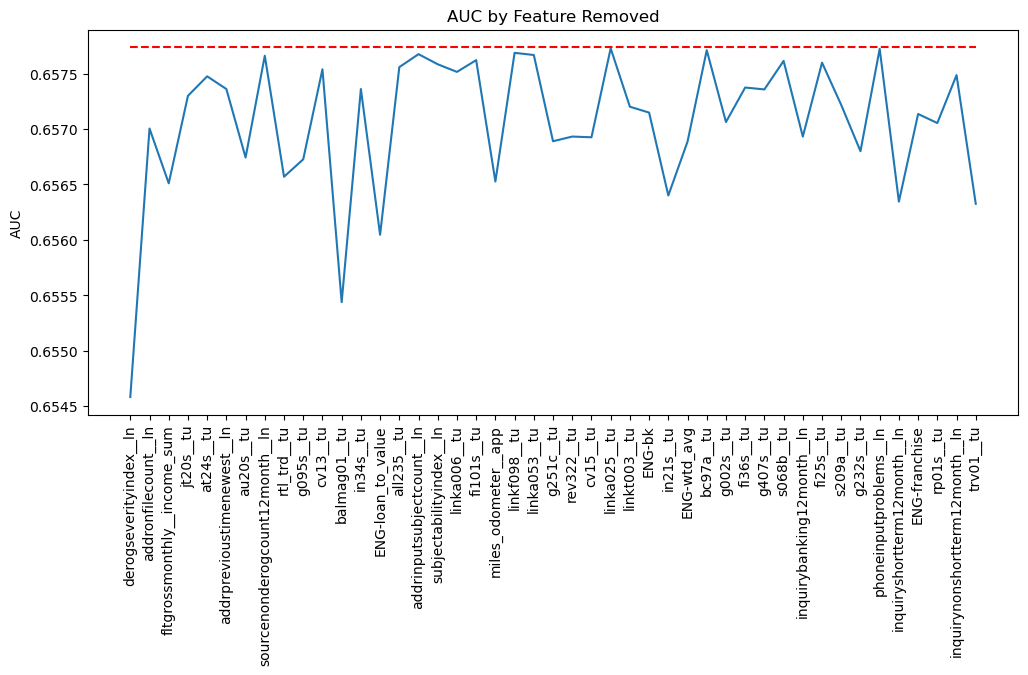

In [20]:
x = df['feature']
y = df['score']
z = df['target']
fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.plot(x, z, linestyle='--', color='red')
ax.set_xticklabels(x, rotation=90)

# save
str_filename = 'disparate_impact.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()